In [1]:
import matplotlib.pyplot as plt
import numpy as np
from lmfit import Minimizer, Parameters
import sys
import pylab as py
import pandas as pd
import csv
import matplotlib.dates as mdates
from scipy import optimize, stats
from importlib import reload
import DataAnalysis.basic_functions as bf
import DataAnalysis.mod_expo_fit_functions as modf
import DataAnalysis.bi_fit_functions as bi_fit
import DataAnalysis.pulser_fit_functions as pf
import DataAnalysis.plot_functions as plotf

sys.path.append('/Users/arleeshelby/ManitobaWork_1374/pyNab/src')
import nabPy as Nab

In [3]:
run_numbers = list(np.arange(8622,8633)) + list(np.arange(8635,8638)) + list(np.arange(8643,8660)) + list(np.arange(8681,8695)) + list(np.arange(8696,8700)) + list(np.arange(8704,8714)) + list(np.arange(8715,8722)) + list(np.arange(8824,8833))+list(np.arange(8834,8836)) + list(np.arange(8837,8851)) + list(np.arange(8853,8866))

In [4]:
UDETdata, UDETtime = bf.get_energy_time_data(run_numbers,'UDET')
LDETdata, LDETtime = bf.get_energy_time_data(run_numbers,'LDET')

In [5]:
UDETenergy = bf.get_energy(run_numbers,UDETdata)
LDETenergy = bf.get_energy(run_numbers,LDETdata)

In [6]:
UDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='UDET')
LDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='LDET')

In [7]:
UDETenergy_pulser = bf.get_energy(run_numbers,UDETdata_pulser)
LDETenergy_pulser = bf.get_energy(run_numbers,LDETdata_pulser)

In [8]:
bin_edges = UDETdata[8715]['bin_edges']['0']['37']
bin_edges_pulser = UDETdata_pulser[8622]['bin_edges']['0']['60']
bin_edges_pulser112 = UDETdata_pulser[8622]['bin_edges']['0']['pulser BC 112']

In [9]:
LDETpixels = ['1009','1010','1011','1012','1013','1017','1018','1019','1020','1021','1022','1023','1026','1027','1028','1029','1030','1031','1032',
               '1033','1037','1038','1039','1040','1041','1042','1043','1044','1047','1048','1049','1050','1051','1052','1053','1054','1055','1056',
               '1060','1061','1062','1062','1063','1064','1065','1066','1067','1068','1069','1072','1073','1074','1075','1076','1077','1078','1079','1080',
               '1081','1084','1085','1086','1087','1088','1089','1090','1091','1092','1094','1095','1096','1098','1099','1100','1101','1102','1105',
               '1107','1108','1109','1111','1116','1117']

In [10]:
UDETpixels = ['9','11','12','17','19','20','21','26','27','28','29','30','31','32','37','38','39','40','41','42','43','47','48','49','50','51','52',
          '53','54','55','60','61','62','63','64','65','66','67','72','73','74','75','76','77','78','79','84','85','86','87','88','89','90','91',
          '94','95','96','97','98','99','100','101','102','105','106','107','108','109','110','115','117']

In [11]:
UDET_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, UDETenergy, bin_edges, UDETpixels, run_numbers, plot=False,detector_type='UDET')

failed Bi fit for run: 8647, pixel: 17, region 1
failed Bi fit for run: 8828, pixel: 17, region 1
failed Bi fit for run: 8847, pixel: 17, region 1
failed Bi fit for run: 8859, pixel: 19, region 1
run: 8630, pixel: 27 too low amp, region 1
failed Bi fit for run: 8689, pixel: 27, region 1
failed Bi fit for run: 8840, pixel: 27, region 1
run: 8624, pixel: 29 too low amp, region 2
failed Bi fit for run: 8834, pixel: 29, region 1
failed Bi fit for run: 8690, pixel: 30, region 1
failed Bi fit for run: 8690, pixel: 30, region 2
failed Bi fit for run: 8715, pixel: 37, region 1
failed Bi fit for run: 8624, pixel: 43, region 1
run: 8624, pixel: 43 too low amp, region 2
run: 8630, pixel: 43 too low amp, region 1
run: 8630, pixel: 43 too low amp, region 2
failed Bi fit for run: 8630, pixel: 43, region 3
run: 8637, pixel: 43 too low amp, region 1
failed Bi fit for run: 8637, pixel: 43, region 2
run: 8683, pixel: 43 too low amp, region 1
run: 8683, pixel: 43 too low amp, region 2
run: 8694, pixel: 4

In [12]:
LDET_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, LDETenergy, bin_edges, LDETpixels, run_numbers, plot=False,detector_type='LDET')


run: 8720, pixel: 1011 too low amp, sig1 or sig2 region 1
failed Bi fit for run: 8720, pixel: 1011, region 3
failed Bi fit for run: 8826, pixel: 1011, region 3
failed Bi fit for run: 8857, pixel: 1011, region 3
LDET average too low, run 8644, pixel 1012
failed Bi fit for run: 8644, pixel: 1012, region 2
LDET average too low, run 8697, pixel 1012
run: 8697, pixel: 1012 too low amp, region 2
failed Bi fit for run: 8719, pixel: 1012, region 1
failed Bi fit for run: 8829, pixel: 1012, region 1
LDET average too low, run 8863, pixel 1012
failed Bi fit for run: 8863, pixel: 1012, region 2
LDET average too low, run 8626, pixel 1013
failed Bi fit for run: 8626, pixel: 1013, region 2
failed Bi fit for run: 8626, pixel: 1013, region 3
LDET average too low, run 8644, pixel 1013
LDET average too low, run 8651, pixel 1013
LDET average too low, run 8685, pixel 1013
failed Bi fit for run: 8685, pixel: 1013, region 2
LDET average too low, run 8697, pixel 1013
LDET average too low, run 8705, pixel 1013


In [13]:
simulated_keV_values = np.array([22.269661+3,35.276915+3,450.020179+3,522.714534+3,535.039+3,
                                 944.193705+3,1016.613371+3,1029.008589+3])
simulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

LDETsimulated_keV_values = np.array([22.269661+30,35.276915+30,450.020179+30,522.714534+30,535.039+30,
                                     944.193705+30,1016.613371+30,1029.008589+30])
LDETsimulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

In [14]:
calibration_peak_data,calibration_width_data,calibration_amp_data = bf.get_cal_peaks_df(UDET_df,simulated_keV_values,simulated_keV_errors)

In [16]:
LDETcalibration_peak_data,LDETcalibration_width_data,LDETcalibration_amp_data = bf.get_cal_peaks_df(LDET_df,LDETsimulated_keV_values,LDETsimulated_keV_errors)

In [17]:
calibration_linear_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='linear')
calibration_quadratic_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='quadratic')

In [18]:
LDETcalibration_linear_results = bf.calibrate_data(LDETcalibration_peak_data,LDETcalibration_amp_data,calibration_order='linear',detector='LDET')
LDETcalibration_quadratic_results = bf.calibrate_data(LDETcalibration_peak_data,LDETcalibration_amp_data,calibration_order='quadratic',detector='LDET')

In [19]:
with open('DatabaseFiles/Runs/run_db.csv') as f:
    csv.DictReader(f)
    metadata = pd.read_csv(f)

In [20]:
metadata

,run_number,UDET_bias,LDET_bias,HV,MAIN,UDET,date,start_time,end_time,ExB,UDET_armor,UDET_ring,LDET_armor,UDET_leakage,LDET_leakage
0,8655,300.0,300.0,27.0,137.0,137.0,2025-10-14,20:51:38,20:51:36,-1499.050847,134.458618,119.984912,129.964194,0.007057,35.94986
1,8709,300.0,300.0,27.0,137.0,137.0,2025-10-21,19:48:30,19:48:28,-1499.000000,134.458499,119.991606,129.974482,0.007585,35.96716
2,8855,300.0,300.0,27.0,137.0,137.0,2025-10-31,15:31:48,15:31:46,-1499.117949,134.275259,120.013290,130.077537,0.007338,35.86735
3,8646,300.0,300.0,27.0,137.0,137.0,2025-10-14,15:35:23,15:35:21,-1499.078125,134.468330,119.999757,129.926447,0.007080,35.94495
4,8848,300.0,300.0,27.0,137.0,137.0,2025-10-30,20:20:45,20:20:43,-1499.000000,134.306473,120.004832,130.048831,0.007573,35.63690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,8720,300.0,300.0,27.0,137.0,137.0,2025-10-22,16:18:29,16:50:08,-1499.028090,134.445196,120.003004,130.028883,0.007329,36.64413
100,8826,300.0,300.0,27.0,137.0,137.0,2025-10-29,19:53:08,20:23:09,-1499.386364,134.329690,119.994170,130.084202,0.008578,36.42743
101,8857,300.0,300.0,27.0,137.0,137.0,2025-10-31,16:42:53,17:17:46,-1499.062802,134.281502,120.014718,130.094448,0.007322,36.35307
102,8719,300.0,300.0,27.0,137.0,137.0,2025-10-22,15:45:26,16:15:26,-1499.269962,134.445041,120.003693,130.040813,0.007344,36.53752


In [1282]:
gain = bf.get_calibration_fit_params(calibration_linear_results,gain=True)
offset = bf.get_calibration_fit_params(calibration_linear_results,offset=True)

LDETgain = bf.get_calibration_fit_params(LDETcalibration_linear_results,gain=True)
LDEToffset = bf.get_calibration_fit_params(LDETcalibration_linear_results,offset=True)

In [1365]:
quad = bf.get_calibration_fit_params(calibration_quadratic_results,quad=True)
quad_gain = bf.get_calibration_fit_params(calibration_quadratic_results,gain=True)
quad_offset = bf.get_calibration_fit_params(calibration_quadratic_results,offset=True)

LDETquad = bf.get_calibration_fit_params(LDETcalibration_quadratic_results,quad=True)
LDETquad_gain = bf.get_calibration_fit_params(LDETcalibration_quadratic_results,gain=True)
LDETquad_offset = bf.get_calibration_fit_params(LDETcalibration_quadratic_results,offset=True)

In [1300]:
average_gain, average_gain_error, gain_std = bf.get_calibration_param_props(gain)
average_gain_weighted, average_gain_error_weighted, gain_std_weighted = bf.get_calibration_param_props(gain,weighted=True)

average_offset, average_offset_error, offset_std = bf.get_calibration_param_props(offset)
average_offset_weighted, average_offset_error_weighted, offset_std_weighted = bf.get_calibration_param_props(offset,weighted=True)

In [1301]:
LDETaverage_gain, LDETaverage_gain_error, LDETgain_std = bf.get_calibration_param_props(LDETgain)
LDETaverage_gain_weighted, LDETaverage_gain_error_weighted, LDETgain_std_weighted = bf.get_calibration_param_props(LDETgain,weighted=True)
LDETaverage_offset, LDETaverage_offset_error, LDEToffset_std = bf.get_calibration_param_props(LDEToffset)
LDETaverage_offset_weighted, LDETaverage_offset_error_weighted, LDEToffset_std_weighted = bf.get_calibration_param_props(LDEToffset,weighted=True)

In [1362]:
average_quad_weighted, average_quad_error_weighted, quad_std_weighted = bf.get_calibration_param_props(quad,weighted=True)
LDETaverage_quad_weighted, LDETaverage_quad_error_weighted, LDETquad_std_weighted = bf.get_calibration_param_props(LDETquad,weighted=True)

In [1388]:
reload(plotf)

<module 'DataAnalysis.plot_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/plot_functions.py'>

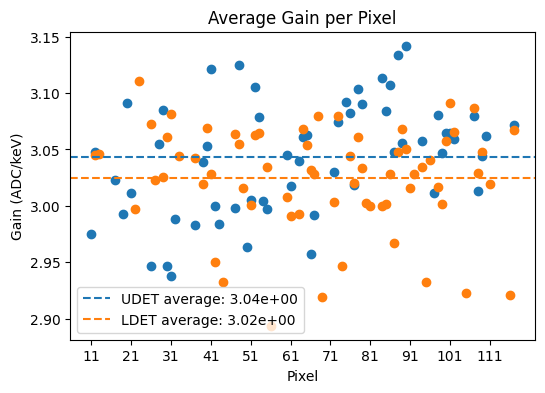

In [1316]:
plotf.plot_calibration_param_props(average_gain_weighted,LDETparam_prop_df=LDETaverage_gain_weighted,title='Average Gain per Pixel',ylabel='Gain (ADC/keV)')




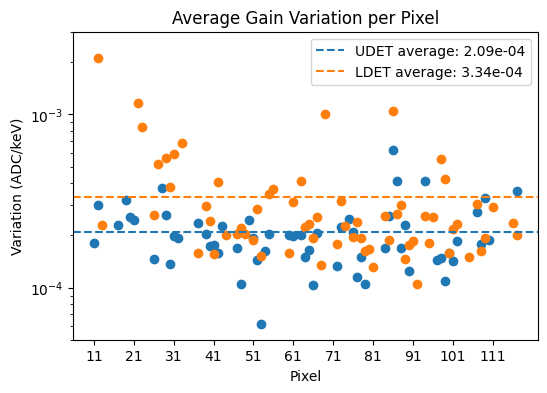

In [1390]:
plotf.plot_calibration_param_props(gain_std_weighted,yscale='log',LDETparam_prop_df=LDETgain_std_weighted,
                                   title='Average Gain Variation per Pixel',ylabel='Variation (ADC/keV)',
                                   bottom_ylim=5e-5,top_ylim=3e-3)



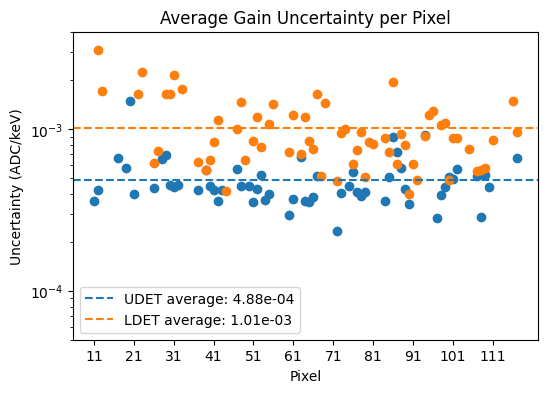

In [1392]:
plotf.plot_calibration_param_props(average_gain_error,yscale='log',LDETparam_prop_df=LDETaverage_gain_error,
                                   title='Average Gain Uncertainty per Pixel',ylabel='Uncertainty (ADC/keV)',
                                   bottom_ylim=5e-5,top_ylim=4e-3)



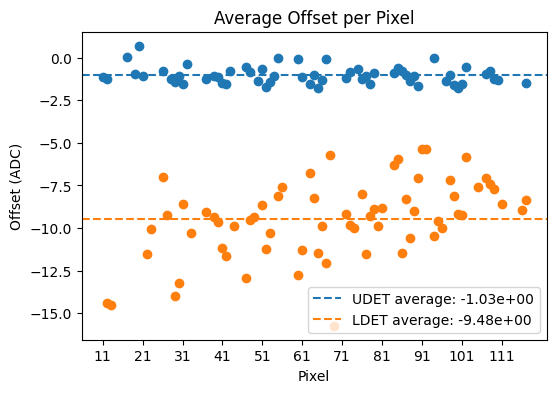

In [1321]:
plotf.plot_calibration_param_props(average_offset_weighted,LDETparam_prop_df=LDETaverage_offset_weighted,title='Average Offset per Pixel',ylabel='Offset (ADC)')



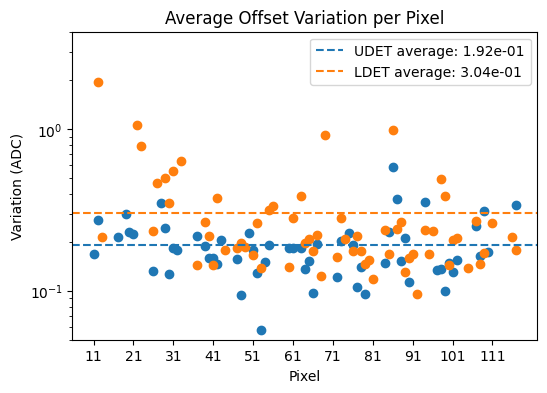

In [1400]:
plotf.plot_calibration_param_props(offset_std_weighted,yscale='log',LDETparam_prop_df=LDEToffset_std_weighted,
                                   title='Average Offset Variation per Pixel',ylabel='Variation (ADC)',
                                   bottom_ylim=5e-2,top_ylim=4)




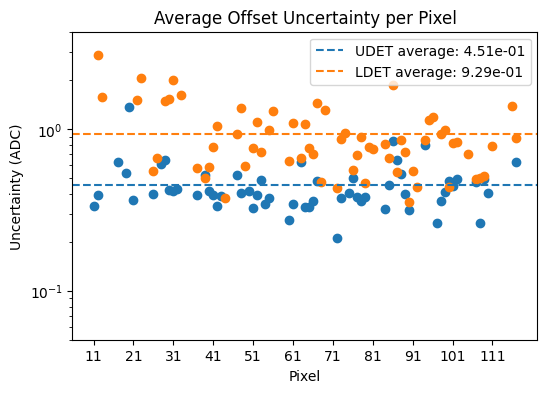

In [1399]:
plotf.plot_calibration_param_props(average_offset_error,yscale='log',LDETparam_prop_df=LDETaverage_offset_error,
                                   title='Average Offset Uncertainty per Pixel',ylabel='Uncertainty (ADC)',
                                   bottom_ylim=5e-2,top_ylim=4)

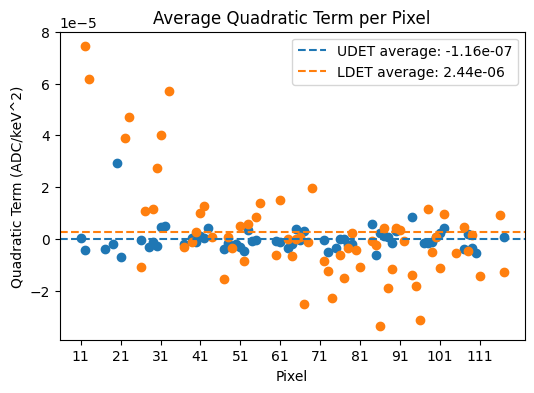

In [1363]:
plotf.plot_calibration_param_props(average_quad_weighted,LDETparam_prop_df=LDETaverage_quad_weighted,title='Average Quadratic Term per Pixel',ylabel='Quadratic Term (ADC/keV^2)')



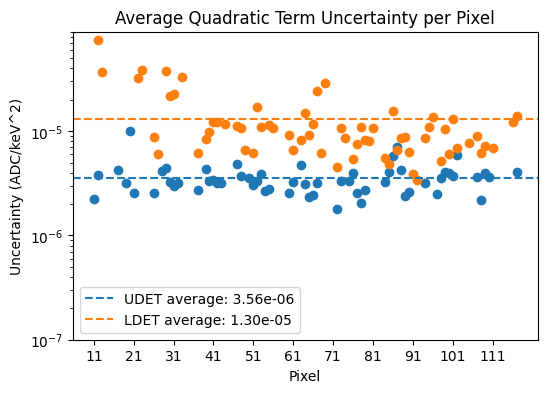

In [1408]:
plotf.plot_calibration_param_props(average_quad_error_weighted,yscale='log',LDETparam_prop_df=LDETaverage_quad_error_weighted,
                                   title='Average Quadratic Term Uncertainty per Pixel',ylabel='Uncertainty (ADC/keV^2)',
                                   bottom_ylim=1e-7,top_ylim=9e-5)




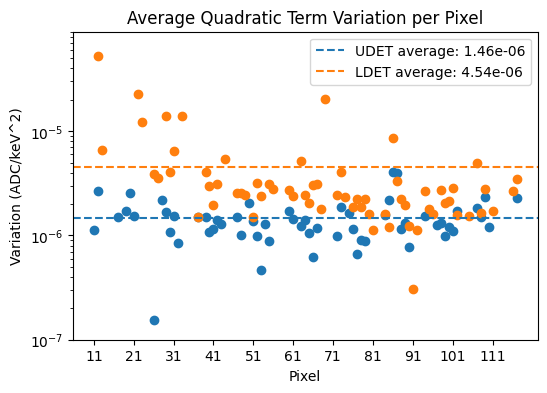

In [1409]:
plotf.plot_calibration_param_props(quad_std_weighted,yscale='log',LDETparam_prop_df=LDETquad_std_weighted,
                                   title='Average Quadratic Term Variation per Pixel',ylabel='Variation (ADC/keV^2)',
                                   bottom_ylim=1e-7,top_ylim=9e-5)


In [1293]:
for key,value in LDETaverage_offset_error.items():
    if value>3:
        print(key,value)

1020 41.39943069230812


In [1536]:
pixel = '1076'
runs = list(LDEToffset[pixel].keys())
for run in runs:
    print(LDEToffset[pixel][run]['error']/LDETgain[pixel][run]['value'])

0.4309916849553007
0.1211996211344192
0.12829772285548546
0.16030945332094837
0.1416065330475903
0.11599705097274644


1012 0.885792452370848
1020 0.885792452370848
1022 0.885792452370848
1023 0.885792452370848
1031 0.885792452370848
1069 0.885792452370848
1086 0.885792452370848


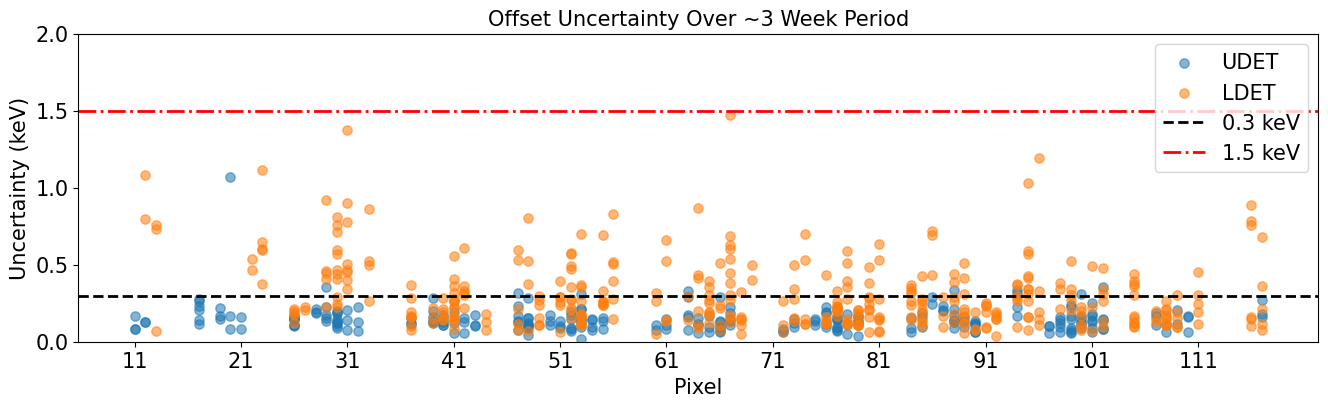

In [1463]:
nrows,ncols=1,1
py.figure(figsize=((16)*ncols,(4)*nrows))
ax=py.subplot(nrows,ncols,1)

pixels = list(offset.keys())
int_pixels = list(map(int, pixels))
for pixel in pixels:
    if pixel=='95':
        continue
    else:
        runs = list(offset[pixel].keys())
        all_uncert = []
        for run in runs:
            uncert = offset[pixel][run]['error']/gain[pixel][run]['value']
            all_uncert.append(uncert)
            if uncert>0.5:
                # print(pixel,run,uncert)
                pass
            if pixel=='11' and run==8655:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55,label='UDET')
            else:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55)
        if any(value<0.3 for value in all_uncert):
            pass
        else:
            print(pixel)
pixels = list(LDEToffset.keys())
for pixel in pixels:
    if pixel=='1043' or pixel=='1054':
        continue
    else:
        runs = list(LDEToffset[pixel].keys())
        LDETall_uncert = []
        for run in runs:
            uncert = LDEToffset[pixel][run]['error']/LDETgain[pixel][run]['value']
            LDETall_uncert.append(uncert)
            if uncert>2:
                # print(pixel,run,uncert)
                pass
            if pixel=='1012' and run==8719:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55,label='LDET')
            else:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55)
        if any(value<0.3 for value in LDETall_uncert):
            pass
        else:
            print(pixel)
ax.set_xticks(range(min(int_pixels),max(int_pixels),10))
ax.set_ylim(0,2)
ax.axhline(0.3,color = 'black', linestyle='dashed',label = '0.3 keV',linewidth=2)
ax.axhline(1.5,color = 'red', linestyle='dashdot',label = '1.5 keV',linewidth=2)
ax.set_xlabel('Pixel',fontsize=15)
ax.set_ylabel('Uncertainty (keV)',fontsize=15)
ax.set_title('Offset Uncertainty Over ~3 Week Period',fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(fontsize=15)
plt.show()

In [1358]:
LDEToffset['1012']

{8719: {'value': -13.639216001726547, 'error': 3.2860278221069557},
 8829: {'value': -15.399724739586103, 'error': 2.4400162348763}}

In [ ]:
y = np.arange(0,1600)
diff = {}
pixels = list(gain.keys())
for pixel in pixels:
    diff[i] = {}
    runs = gain.keys
    for run in cal_result[i]['m'].keys():
        quad = cal_result[i]['q1'][j]*y**2 +cal_result[i]['q2'][j]*y + cal_result[i]['q3'][j]
        lin = cal_result[i]['m'][j]*y + cal_result[i]['b'][j]
        full_diff = quad-lin
        if cal_result[i]['q1'][j]>0:
            diff[i][j] = np.min(full_diff)
        if cal_result[i]['q1'][j]<0:
            diff[i][j] = np.max(full_diff)

In [1376]:
y = np.arange(0,1600)
pixels = list(offset.keys())
int_pixels = list(map(int, pixels))
diff = {}
for pixel in pixels:
    if pixel=='95':
        continue
    else:
        diff[pixel] = {}
        runs = list(offset[pixel].keys())
        all_uncert = []
        for run in runs:
            quadratic = quad[pixel][run]['value']*y**2 + quad_gain[pixel][run]['value']*y + quad_offset[pixel][run]['value']
            lin = gain[pixel][run]['value']*y + offset[pixel][run]['value']
            full_diff = quadratic-lin
            if quad[pixel][run]['value']>0:
                diff[pixel][run] = np.min(full_diff)/gain[pixel][run]['value']
            if quad[pixel][run]['value']<0:
                diff[pixel][run] = np.max(full_diff)/gain[pixel][run]['value']

In [1377]:
y = np.arange(0,1600)
pixels = list(LDEToffset.keys())
LDETint_pixels = list(map(int, pixels))
LDETdiff = {}
for pixel in pixels:
    if pixel=='1043' or pixel=='1054':
        continue
    else:
        LDETdiff[pixel] = {}
        runs = list(LDEToffset[pixel].keys())
        all_uncert = []
        for run in runs:
            quadratic = LDETquad[pixel][run]['value']*y**2 + LDETquad_gain[pixel][run]['value']*y + LDETquad_offset[pixel][run]['value']
            lin = LDETgain[pixel][run]['value']*y + LDEToffset[pixel][run]['value']
            full_diff = quadratic-lin
            if LDETquad[pixel][run]['value']>0:
                LDETdiff[pixel][run] = np.min(full_diff)/LDETgain[pixel][run]['value']
            if LDETquad[pixel][run]['value']<0:
                LDETdiff[pixel][run] = np.max(full_diff)/LDETgain[pixel][run]['value']

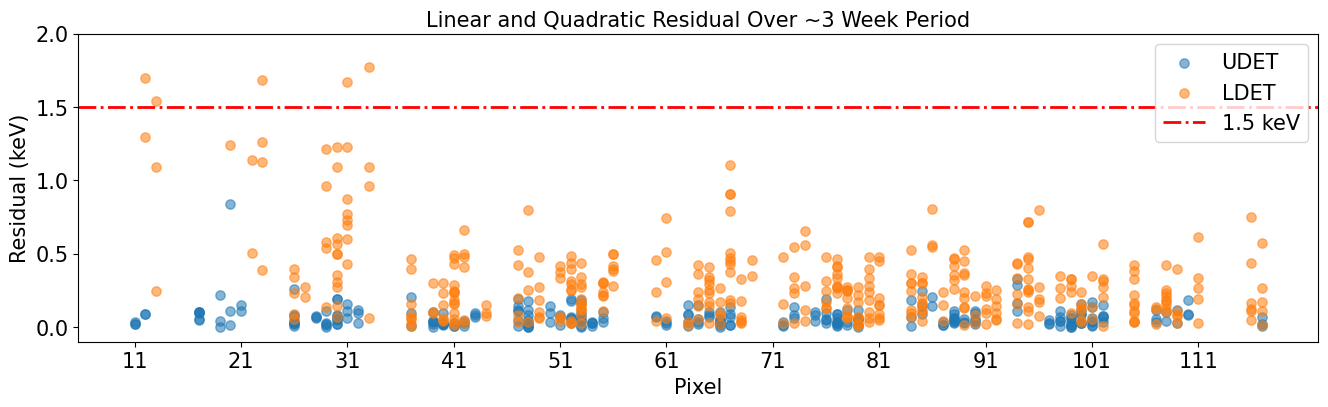

In [1386]:
nrows,ncols=1,1
py.figure(figsize=((16)*ncols,(4)*nrows))
ax=py.subplot(nrows,ncols,1)

pixels = list(diff.keys())
int_pixels = list(map(int, pixels))
for pixel in pixels:
    if pixel=='95':
        continue
    else:
        runs = list(diff[pixel].keys())
        all_uncert = []
        for run in runs:
            uncert = np.abs(diff[pixel][run])
            all_uncert.append(uncert)
            if pixel=='11' and run==8655:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55,label='UDET')
            else:
                ax.scatter(int(pixel),uncert,color='C0',s=45,alpha=0.55)
        if any(value<1.5 for value in all_uncert):
            pass
        else:
            print(pixel)
pixels = list(LDETdiff.keys())
for pixel in pixels:
    if pixel=='1043' or pixel=='1054':
        continue
    else:
        runs = list(LDETdiff[pixel].keys())
        LDETall_uncert = []
        for run in runs:
            uncert = np.abs(LDETdiff[pixel][run])
            LDETall_uncert.append(uncert)
            if pixel=='1012' and run==8719:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55,label='LDET')
            else:
                ax.scatter(int(pixel)-1000,uncert,color='C1',s=45,alpha=0.55)
        if any(value<1.5 for value in LDETall_uncert):
            pass
        else:
            print(pixel)
ax.set_xticks(range(min(int_pixels),max(int_pixels),10))
ax.set_ylim(-0.1,2)
# ax.axhline(0.3,color = 'black', linestyle='dashed',label = '0.3 keV',linewidth=2)
ax.axhline(1.5,color = 'red', linestyle='dashdot',label = '1.5 keV',linewidth=2)
ax.set_xlabel('Pixel',fontsize=15)
ax.set_ylabel('Residual (keV)',fontsize=15)
ax.set_title('Linear and Quadratic Residual Over ~3 Week Period',fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(fontsize=15)
plt.show()